# Cross-Domain Recommendation with EMCDR
*Cold-start recommendation by transferring user taste across Amazon verticals.*

Walkthrough order: **raw-data EDA → preprocessing → processed-data EDA → baselines → our solution (EMCDR) → improvements & honest boundary.**

> Every number and figure below is **computed in-notebook** from `data/raw/` and `data/processed/` — nothing is pasted from a Markdown report. The two heavy passes over the raw corpus (≈5 GB of CSVs, ≈20 GB of JSONL) run once and cache to `notebooks/_cache/`, so a re-run is instant. The final **verification** cell cross-checks every live EDA figure against the §3 preprocessing artifact (`dataset_description.json`, produced by `notebooks/data_prep.ipynb`) and asserts they agree.

## Setup

In [1]:
# ── Setup: imports, brand theme, paths, palette ────────────────────────────
import os, json, gc, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch, FancyBboxPatch, FancyArrowPatch
import seaborn as sns
warnings.filterwarnings('ignore')

# ---- brand palette ---------------------------------------------------------
BG        = '#F7F7FC'   # page background (soft lavender)
INK       = '#2B2D42'   # titles / primary text
INK_SOFT  = '#6E6B85'   # axis labels / secondary text
GRIDC     = '#E7E4F1'   # hairline grid
SPINEC    = '#CFCADB'   # baseline spine

PURPLE    = '#6C4DF6'   # hero / primary
PURPLE_DK = '#4A2FD0'
PURPLE_LT = '#B6A9F7'
ORANGE    = '#F7A81B'   # highlight accent
CORAL     = '#F65C6C'   # negative
TEAL      = '#16C2C2'
GREEN     = '#23B26D'
NEUTRAL   = '#CBC6DD'   # muted neutral
NAVY      = PURPLE      # back-compat alias used by later cells

# 5 distinguishable, on-brand hues — one per vertical
VERT_PAL  = ['#6C4DF6', '#9B5DE5', '#F15BB5', '#F7A81B', '#16C2C2']
# white -> purple sequential map for heatmaps
PURPLES   = LinearSegmentedColormap.from_list(
    'brand_purples', ['#FFFFFF', '#DCD3FB', '#9B86F2', PURPLE, PURPLE_DK])

# ---- matplotlib theme ------------------------------------------------------
plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'font.family': 'DejaVu Sans', 'font.size': 12,
    'text.color': INK, 'axes.labelcolor': INK_SOFT,
    'xtick.color': INK_SOFT, 'ytick.color': INK_SOFT,
    'axes.titlesize': 15, 'axes.titleweight': 'bold',
    'axes.labelsize': 11.5, 'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False, 'axes.spines.bottom': True,
    'axes.edgecolor': SPINEC, 'axes.linewidth': 1.1, 'axes.grid': False,
    'figure.facecolor': BG, 'axes.facecolor': BG, 'savefig.facecolor': BG,
    'xtick.major.size': 0, 'ytick.major.size': 0,
})

# ---- reusable style helpers ------------------------------------------------
def style_bar_axis(ax, axis='x'):
    """Strip the frame down to a single baseline spine; tint the panel."""
    ax.set_facecolor(BG)
    for s in ax.spines.values(): s.set_visible(False)
    base = 'bottom' if axis == 'x' else 'left'
    ax.spines[base].set_visible(True)
    ax.spines[base].set_color(SPINEC); ax.spines[base].set_linewidth(1.1)
    ax.tick_params(length=0); ax.grid(False)

def style_line_axis(ax):
    ax.set_facecolor(BG)
    for s in ax.spines.values(): s.set_visible(False)
    ax.spines['bottom'].set_visible(True); ax.spines['bottom'].set_color(SPINEC)
    ax.tick_params(length=0)
    ax.grid(True, color=GRIDC, lw=0.9); ax.set_axisbelow(True)

def soft_grid(ax, axis='y'):
    ax.grid(axis=axis, color=GRIDC, lw=0.9); ax.set_axisbelow(True)

def ctitle(ax, text, pad=14, size=13.5):
    ax.set_title(text, loc='center', color=INK, fontweight='bold', pad=pad, fontsize=size)

def brand_legend(ax, **kw):
    kw.setdefault('frameon', False)
    leg = ax.legend(**kw)
    for t in leg.get_texts(): t.set_color(INK)
    return leg

# ---- paths -----------------------------------------------------------------
ROOT = Path(os.environ.get('AMAZON_CR_ROOT', '/Users/orimood/Desktop/homework/Amazon_CR'))
if not ROOT.exists():                      # portable fallback (e.g. run from ./notebooks)
    _here = Path.cwd(); ROOT = _here.parent if _here.name == 'notebooks' else _here
PROC  = ROOT / 'data' / 'processed'
RES   = ROOT / 'results'
CACHE = ROOT / 'notebooks' / '_cache'

VERTICALS = ['Books', 'Movies_and_TV', 'CDs_and_Vinyl', 'Video_Games', 'Toys_and_Games']
LBL = {'Books':'Books', 'Movies_and_TV':'Movies & TV', 'CDs_and_Vinyl':'CDs & Vinyl',
       'Video_Games':'Video Games', 'Toys_and_Games':'Toys & Games',
       'Video_Games_3core':'Video Games (3-core)'}
SHORT = {'Books':'Books', 'Movies_and_TV':'Movies', 'CDs_and_Vinyl':'CDs',
         'Video_Games':'V.Games', 'Toys_and_Games':'Toys', 'Video_Games_3core':'V.Games³ᶜ'}

# per-vertical categorical colors (consistent across every EDA figure)
VCOLORS = {v: VERT_PAL[i] for i, v in enumerate(VERTICALS)}

# model colors: baselines muted, EMCDR the single saturated accent
MODEL_COLORS = {'emcdr':PURPLE, 'baseline_target_mf':ORANGE,
                'baseline_feature_transfer':TEAL, 'baseline_mostpop':PURPLE_LT,
                'baseline_random':NEUTRAL}
MODEL_LBL = {'emcdr':'EMCDR', 'baseline_target_mf':'target-MF',
             'baseline_feature_transfer':'content-transfer', 'baseline_mostpop':'MostPop',
             'baseline_random':'Random'}
HEADLINE = 'Recall@10'
print('setup ready ·', plt.rcParams['figure.dpi'], 'dpi ·', len(VERTICALS),
      'verticals · root', ROOT.name)

setup ready · 130.0 dpi · 5 verticals · root Amazon_CR


In [2]:
# ── Generic plot helpers + study constants (used everywhere below) ──────────
def kfmt(n):
    n = float(n)
    if n >= 1e6: return f'{n/1e6:.1f}M'
    if n >= 1e3: return f'{n/1e3:.0f}k'
    return f'{n:.0f}'

def finish(fig):
    fig.tight_layout(); plt.show()

def bar_annotated(ax, bars, vals, fmt='{:.3f}', fs=9, dy=None, color=INK):
    if dy is None:
        dy = 0.012 * max([b.get_height() for b in bars] + [1e-9])
    for b, v in zip(bars, vals):
        if np.isnan(v): continue
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+dy, fmt.format(v),
                ha='center', va='bottom', fontsize=fs, color=color, fontweight='bold')

def plabel(s, t):  return f'{SHORT[s]}→{SHORT[t]}'
def arr_lbl(s, t): return f'{SHORT[s]} → {LBL[t]}'

# the 8 study pairs, ordered by shared-user overlap (descending)
PAIRS_FULL = [('Books','Movies_and_TV'), ('Books','Toys_and_Games'),
              ('Movies_and_TV','Toys_and_Games'), ('Movies_and_TV','CDs_and_Vinyl'),
              ('Books','CDs_and_Vinyl'), ('Movies_and_TV','Video_Games'),
              ('Toys_and_Games','Video_Games'), ('Books','Video_Games')]
# "deployed" config: 5 rich pairs from the regularized-linear map, 3 Video-Games pairs from 3-core
DEPLOYED = [('Books','Movies_and_TV','improve_lin'), ('Books','Toys_and_Games','improve_lin'),
            ('Movies_and_TV','Toys_and_Games','improve_lin'), ('Movies_and_TV','CDs_and_Vinyl','improve_lin'),
            ('Books','CDs_and_Vinyl','improve_lin'), ('Movies_and_TV','Video_Games_3core','b1_3core'),
            ('Toys_and_Games','Video_Games_3core','b1_3core'), ('Books','Video_Games_3core','b1_3core')]
print('plot helpers ready ·', len(PAIRS_FULL), 'study pairs')

plot helpers ready · 8 study pairs


In [3]:
# ── §3 preprocessing artifact: REFERENCE ONLY (never a data source for figures) ──
# Produced by notebooks/data_prep.ipynb. We compute every EDA number live from
# data/raw + data/processed, then check() it against this artifact. The eda.ipynb
# notebook computes the same quantities upstream, so a match here means all three
# agree. Discrepancies are surfaced (and asserted) in the final Verification cell.
DESC  = json.load(open(PROC / 'dataset_description.json'))
def dsel(v):    return DESC['verticals'][v]['select']
def dcln(v):    return DESC['verticals'][v]['clean']
def dpair(s,t): return DESC['pairs'][f'{s}__{t}']

CHECKS = []   # (name, computed, reference, ok)
def check(name, computed, reference):
    CHECKS.append((name, computed, reference, computed == reference)); return computed
def check_ge(name, computed, reference):
    CHECKS.append((name, computed, f'>={reference:,}', computed >= reference)); return computed

print('reference loaded ·', len(DESC['verticals']), 'verticals ·', len(DESC['pairs']), 'pairs ·',
      'category vocab', DESC['category_vocab_size'])

reference loaded · 5 verticals · 8 pairs · category vocab 3092


## 1 · Raw-data EDA — *before any filtering*

The five verticals as they ship: the **0-core** rating tables (`data/raw/reviews/*.csv`) and the raw item metadata (`data/raw/meta/*.jsonl`). Two heavy passes — one over the rating/timestamp/user columns, one streaming the metadata — run once and cache to `notebooks/_cache/`; the figures then read the cache. This mirrors `notebooks/eda.ipynb` §2.2–§2.3.

In [4]:
# ── Heavy pass #1: raw reviews → 0-core volumetric, rating + yearly histograms,
#    and the 0-core user sets for the pairwise-overlap matrix. (~1–2 min first run.)
import pyarrow.csv as pacsv
import pyarrow.compute as pc
CACHE.mkdir(parents=True, exist_ok=True)
RAW = ROOT / 'data' / 'raw'

def _read_reviews(v):
    return pacsv.read_csv(RAW / 'reviews' / f'{v}.csv',
        convert_options=pacsv.ConvertOptions(column_types={
            'user_id':'string', 'parent_asin':'string',
            'rating':'float32', 'timestamp':'int64'}))

def build_raw_reviews_cache():
    rev, uniq = {}, {}
    for v in VERTICALS:
        t = _read_reviews(v)
        rating = t['rating'].to_numpy().astype('int64')
        vals, cnts = np.unique(rating, return_counts=True)
        yr = pd.Series(pd.to_datetime(t['timestamp'].to_numpy(), unit='ms', errors='coerce')).dt.year
        yhist = yr.dropna().astype('int64').value_counts().sort_index()
        rev[v] = {
            'interactions_0core': int(t.num_rows),
            'users_0core':        int(pc.count_distinct(t['user_id']).as_py()),
            'items_0core':        int(pc.count_distinct(t['parent_asin']).as_py()),
            'rating_hist':        {int(k): int(c) for k, c in zip(vals, cnts)},
            'yearly':             {int(y): int(c) for y, c in yhist.items()},
        }
        uniq[v] = pd.Index(pc.unique(t['user_id']).to_pandas())     # 0-core user set
        del t; gc.collect()
        print(f'  {v:16s} inter={rev[v]["interactions_0core"]:>11,d}  '
              f'users={rev[v]["users_0core"]:>10,d}  items={rev[v]["items_0core"]:>9,d}')
    # 0-core pairwise user-overlap matrix (5×5; diagonal = vertical size)
    M = np.zeros((len(VERTICALS),) * 2, dtype='int64')
    for i, a in enumerate(VERTICALS):
        for j, b in enumerate(VERTICALS):
            M[i, j] = len(uniq[a]) if i == j else len(uniq[a].intersection(uniq[b]))
    json.dump(rev, open(CACHE / 'raw_reviews.json', 'w'))
    json.dump({'verticals': VERTICALS, 'matrix': M.tolist()}, open(CACHE / 'overlap0.json', 'w'))
    return rev

if (CACHE / 'raw_reviews.json').exists() and (CACHE / 'overlap0.json').exists():
    RAWREV = json.load(open(CACHE / 'raw_reviews.json'));  print('raw-reviews cache loaded')
else:
    print('building raw-reviews cache (first run reads ~5 GB of CSVs, ~1–2 min)…')
    RAWREV = build_raw_reviews_cache()
OVL0 = json.load(open(CACHE / 'overlap0.json'))

# JSON stringifies int dict-keys — restore them
for v in RAWREV:
    RAWREV[v]['rating_hist'] = {int(k): int(c) for k, c in RAWREV[v]['rating_hist'].items()}
    RAWREV[v]['yearly']      = {int(k): int(c) for k, c in RAWREV[v]['yearly'].items()}

building raw-reviews cache (first run reads ~5 GB of CSVs, ~1–2 min)…


  Books            inter= 29,139,329  users=10,297,355  items=4,446,065


  Movies_and_TV    inter= 17,158,519  users= 6,503,429  items=  747,764


  CDs_and_Vinyl    inter=  4,772,071  users= 1,754,118  items=  701,673


  Video_Games      inter=  4,555,500  users= 2,766,656  items=  137,249


  Toys_and_Games   inter= 16,052,440  users= 8,116,226  items=  890,667


### 1.1 · Catalog scale (0-core, raw)

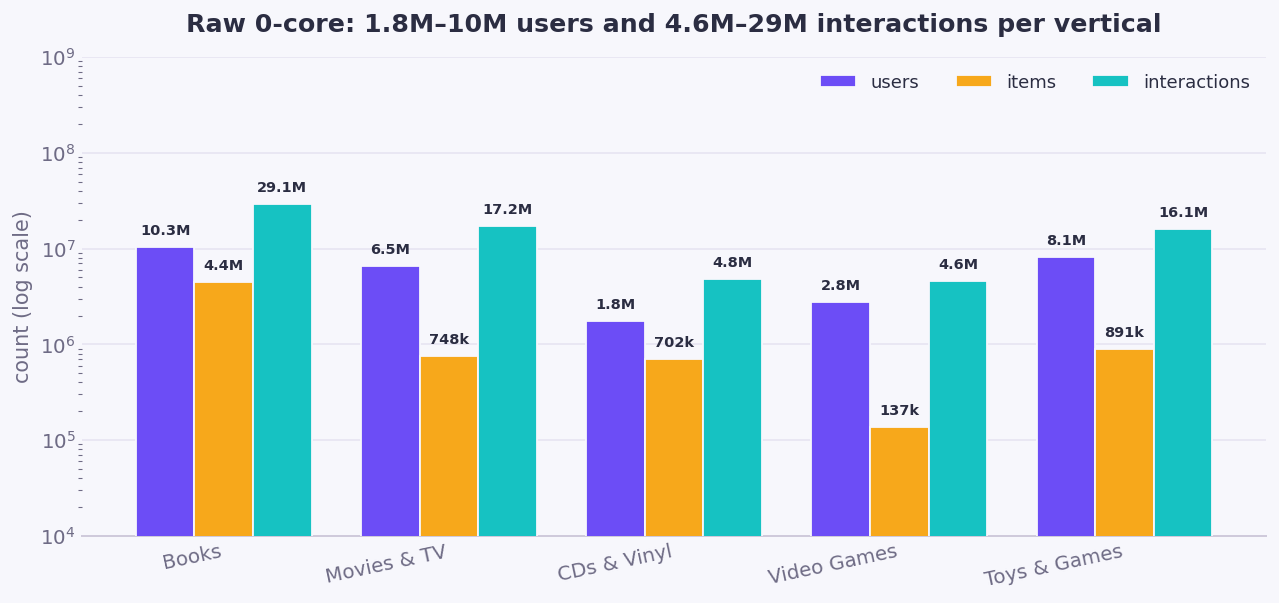

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.8))
metrics = [('users_0core', 'users', PURPLE),
           ('items_0core', 'items', ORANGE),
           ('interactions_0core', 'interactions', TEAL)]
x = np.arange(len(VERTICALS)); w = 0.26
for k, (key, name, col) in enumerate(metrics):
    vals = [RAWREV[v][key] for v in VERTICALS]
    bars = ax.bar(x + (k-1)*w, vals, w, label=name, color=col, edgecolor=BG, zorder=3)
    for b, val in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, val*1.25, kfmt(val), ha='center', va='bottom',
                fontsize=8, color=INK, fontweight='bold')
ax.set_yscale('log'); ax.set_ylim(1e4, 1e9)
ax.set_xticks(x); ax.set_xticklabels([LBL[v] for v in VERTICALS], rotation=12, ha='right')
ax.set_ylabel('count (log scale)')
ctitle(ax, 'Raw 0-core: 1.8M–10M users and 4.6M–29M interactions per vertical', size=14)
style_bar_axis(ax, 'x'); soft_grid(ax, 'y')
brand_legend(ax, ncol=3, loc='upper right')
for v in VERTICALS:
    check(f'{v}.users_0core',        RAWREV[v]['users_0core'],        dsel(v)['users_0core'])
    check(f'{v}.items_0core',        RAWREV[v]['items_0core'],        dsel(v)['items_0core'])
    check(f'{v}.interactions_0core', RAWREV[v]['interactions_0core'], dsel(v)['interactions_0core'])
finish(fig)

### 1.2 · Rating distribution
The binary label the whole project rests on: **≥4★ → positive**, **{1,2}★ → explicit negative**, **3★ dropped**. Most interactions are ≥4★, so positives are plentiful even after the 5-core prune.

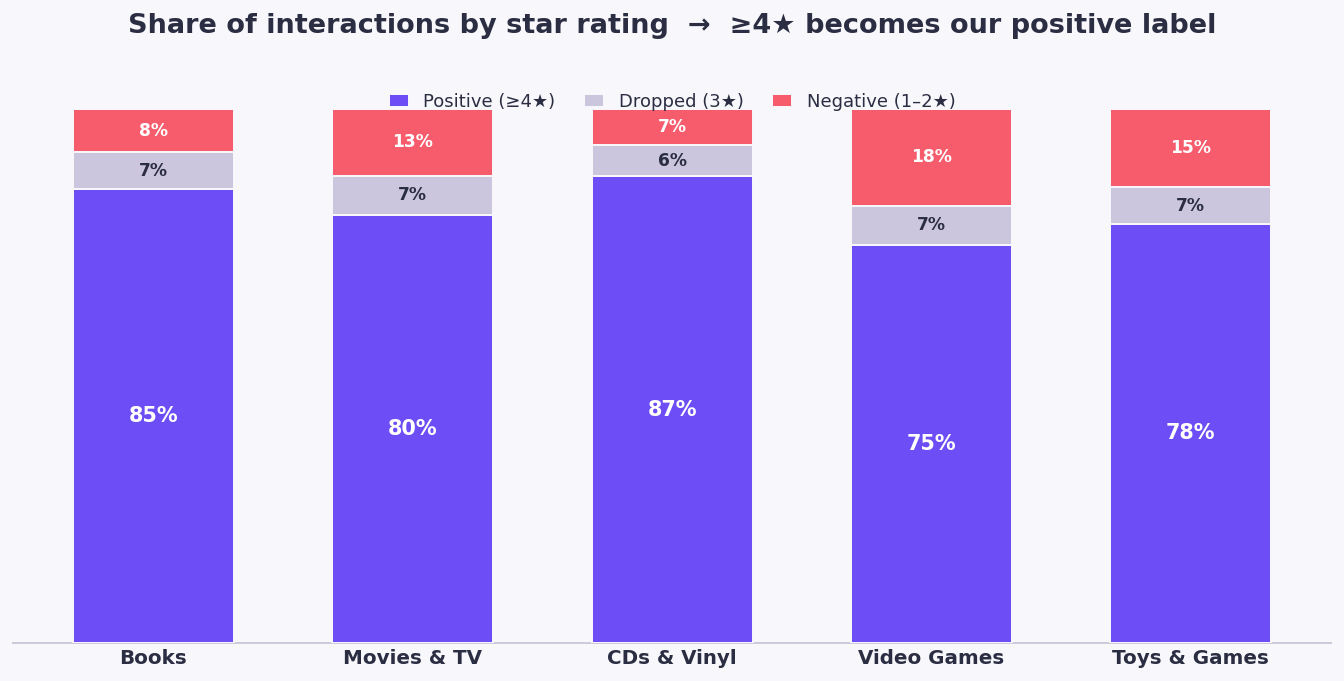

In [6]:
order = VERTICALS
def rh(v): return RAWREV[v]['rating_hist']
tot = {v: sum(rh(v).values()) for v in order}
pos = [(rh(v).get(4,0) + rh(v).get(5,0)) / tot[v] * 100 for v in order]            # >=4 star
neu = [ rh(v).get(3,0)                    / tot[v] * 100 for v in order]            # 3 star
neg = [(rh(v).get(0,0) + rh(v).get(1,0) + rh(v).get(2,0)) / tot[v] * 100 for v in order]  # 0–2 star
fig, ax = plt.subplots(figsize=(10.5, 5.4))
x = np.arange(len(order)); w = 0.62
ax.bar(x, pos, w, color=PURPLE,  edgecolor=BG, linewidth=1.1, label='Positive (≥4★)', zorder=3)
ax.bar(x, neu, w, bottom=pos, color=NEUTRAL, edgecolor=BG, linewidth=1.1, label='Dropped (3★)', zorder=3)
ax.bar(x, neg, w, bottom=np.array(pos)+np.array(neu), color=CORAL, edgecolor=BG, linewidth=1.1,
       label='Negative (1–2★)', zorder=3)
for i in range(len(order)):
    ax.text(i, pos[i]/2, f'{pos[i]:.0f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=11.5)
    ax.text(i, pos[i]+neu[i]/2, f'{neu[i]:.0f}%', ha='center', va='center', color=INK, fontweight='bold', fontsize=9.5)
    ax.text(i, pos[i]+neu[i]+neg[i]/2, f'{neg[i]:.0f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=9.5)
ax.set_ylim(0, 100); ax.set_yticks([])
ax.set_xticks(x); ax.set_xticklabels([LBL[v] for v in order], fontweight='bold', color=INK)
ctitle(ax, 'Share of interactions by star rating  →  ≥4★ becomes our positive label', size=15, pad=42)
style_bar_axis(ax, 'x')
brand_legend(ax, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.06), handlelength=1.1, columnspacing=1.6)
finish(fig)

### 1.3 · Activity over time

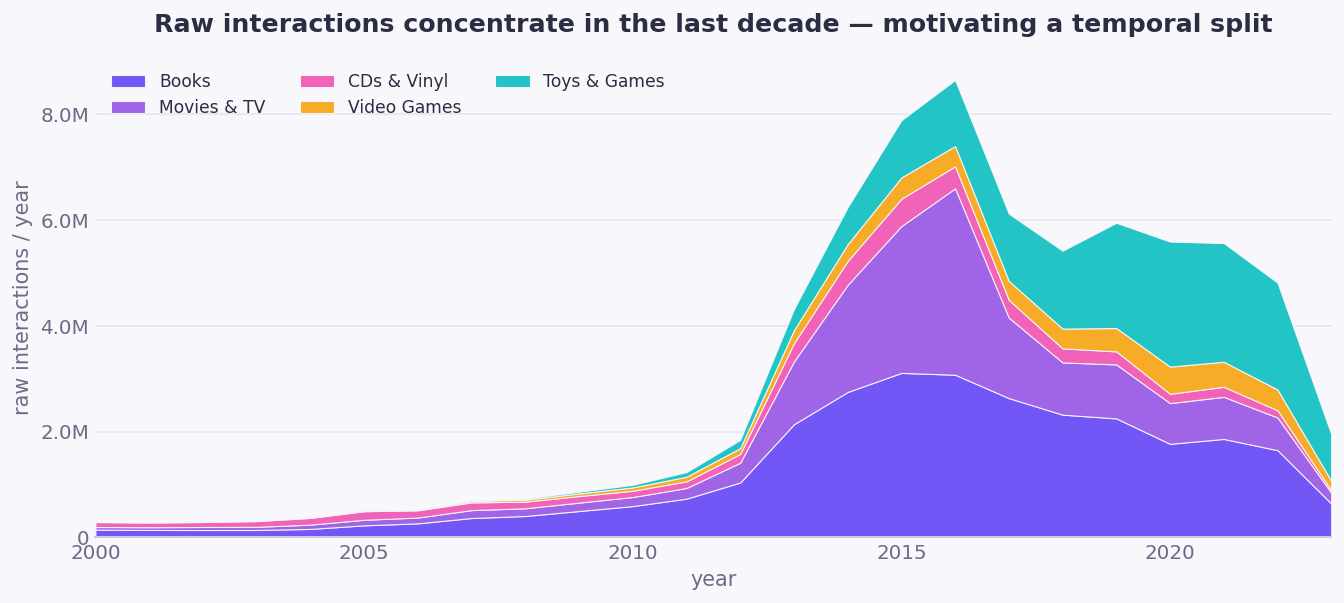

In [7]:
piv = pd.DataFrame({v: pd.Series(RAWREV[v]['yearly']) for v in VERTICALS}).fillna(0)
piv = piv[(piv.index >= 2000) & (piv.index <= 2023)].sort_index()
fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.stackplot(piv.index.values, [piv[v].values for v in VERTICALS],
             labels=[LBL[v] for v in VERTICALS], colors=[VCOLORS[v] for v in VERTICALS],
             alpha=0.95, edgecolor=BG, linewidth=0.6)
ax.set_xlim(2000, 2023); ax.set_xlabel('year'); ax.set_ylabel('raw interactions / year')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: kfmt(v)))
ctitle(ax, 'Raw interactions concentrate in the last decade — motivating a temporal split', size=14)
style_bar_axis(ax, 'x'); soft_grid(ax, 'y')
brand_legend(ax, ncol=3, loc='upper left', fontsize=9.5)
finish(fig)

### 1.4 · Catalog metadata coverage
Why the cleaning step needs a text-fallback chain: most verticals are metadata-rich, but **Movies & TV** is sparse across the rich-text fields, so some items must fall back to `title + store + details`.

In [8]:
# ── Heavy pass #2: stream raw metadata JSONL → per-field populated rate over ALL
#    raw items. (~1.5–2 min first run; Books meta alone is ~14 GB.) Mirrors eda.ipynb §2.2.5.
from collections import Counter
POP_FIELDS = ['title', 'description', 'features', 'categories', 'main_category', 'store', 'details', 'price']

def build_raw_meta_cache():
    out = {}
    for v in VERTICALS:
        n = 0; pop = Counter()
        with open(RAW / 'meta' / f'meta_{v}.jsonl') as f:
            for line in f:
                n += 1; r = json.loads(line)
                for k in ('title', 'main_category', 'store'):
                    x = r.get(k)
                    if isinstance(x, str) and x.strip(): pop[k] += 1
                for k in ('description', 'features', 'categories'):
                    x = r.get(k)
                    if isinstance(x, list) and len(x) > 0: pop[k] += 1
                if isinstance(r.get('details'), dict) and len(r['details']) > 0: pop['details'] += 1
                if r.get('price') is not None: pop['price'] += 1
        out[v] = {'n_items': n, 'pop': dict(pop)}
        print(f'  {v:16s} raw items={n:>9,d}')
    json.dump(out, open(CACHE / 'raw_meta.json', 'w'))
    return out

if (CACHE / 'raw_meta.json').exists():
    RAWMETA = json.load(open(CACHE / 'raw_meta.json')); print('raw-meta cache loaded')
else:
    print('building raw-meta cache (first run streams ~20 GB of JSONL, ~1.5–2 min)…')
    RAWMETA = build_raw_meta_cache()

POPMAT = np.array([[RAWMETA[v]['pop'].get(f, 0) / RAWMETA[v]['n_items'] * 100 for f in POP_FIELDS]
                   for v in VERTICALS])

building raw-meta cache (first run streams ~20 GB of JSONL, ~1.5–2 min)…


  Books            raw items=4,448,181


  Movies_and_TV    raw items=  748,224


  CDs_and_Vinyl    raw items=  701,959


  Video_Games      raw items=  137,269


  Toys_and_Games   raw items=  890,874


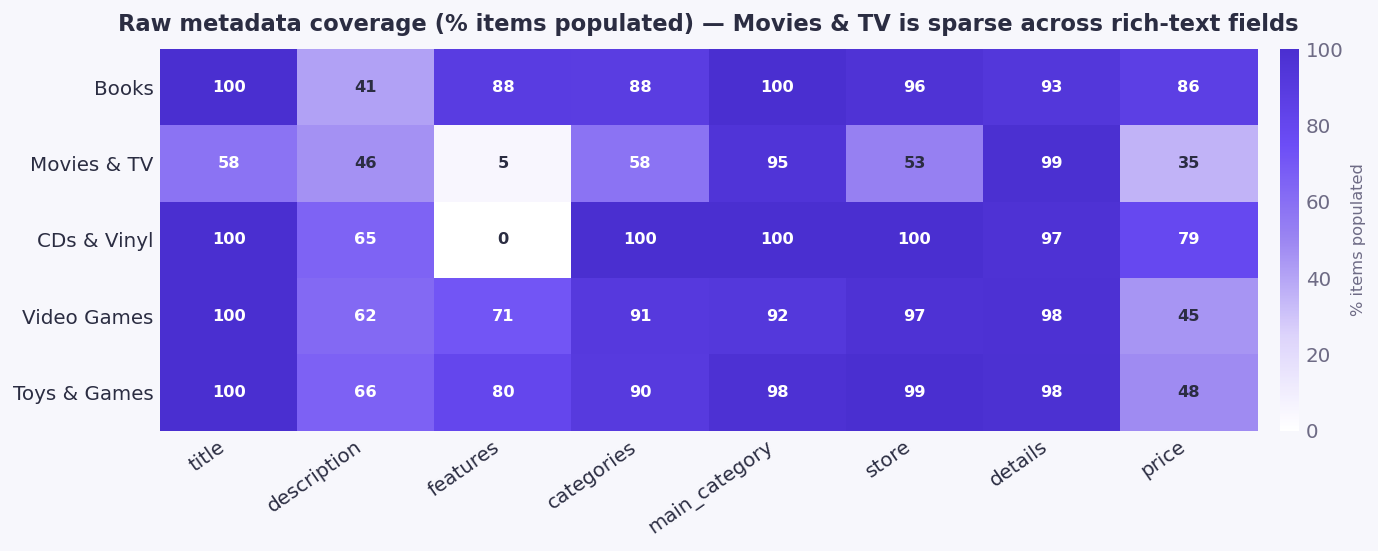

In [9]:
M = POPMAT
fig, ax = plt.subplots(figsize=(10.8, 4.4))
im = ax.imshow(M, cmap=PURPLES, vmin=0, vmax=100, aspect='auto')
ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xticks(range(len(POP_FIELDS))); ax.set_xticklabels(POP_FIELDS, rotation=35, ha='right', color=INK)
ax.set_yticks(range(len(VERTICALS))); ax.set_yticklabels([LBL[v] for v in VERTICALS], color=INK)
ax.tick_params(length=0)
for i in range(len(VERTICALS)):
    for j in range(len(POP_FIELDS)):
        ax.text(j, i, f'{M[i,j]:.0f}', ha='center', va='center', fontsize=9,
                color='white' if M[i,j] > 55 else INK, fontweight='bold')
ctitle(ax, 'Raw metadata coverage (% items populated) — Movies & TV is sparse across rich-text fields', size=12.5, pad=10)
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_label('% items populated', fontsize=9, color=INK_SOFT)
cb.outline.set_visible(False); cb.ax.tick_params(length=0, colors=INK_SOFT)
finish(fig)

### 1.5 · Pairwise user overlap (0-core)
The single most important EDA output: how many users two verticals share. This decides which source→target pairs are even trainable for EMCDR. Of the 10 possible pairs, **8 clear the ~10k shared-user floor** (after the 5-core prune, §3); the two thinnest (**Toys ↔ CDs**, **CDs ↔ Video Games**) fall below it and are excluded.

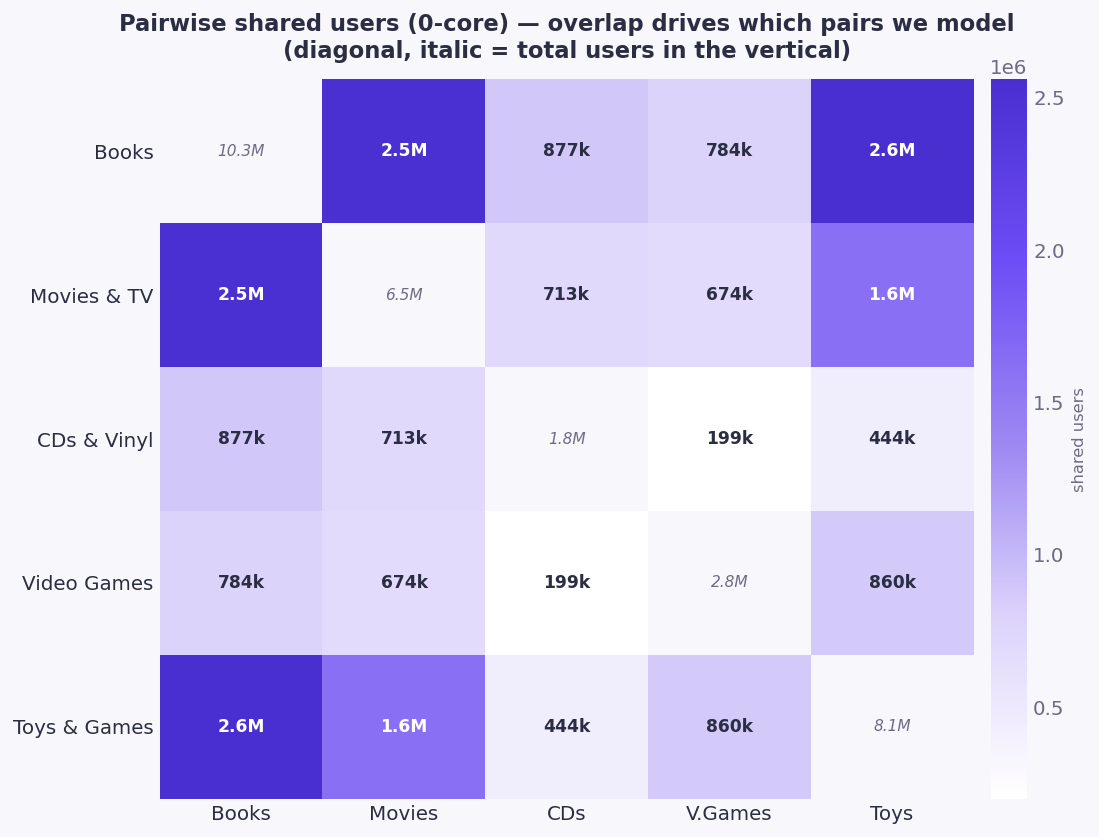

In [10]:
M  = np.array(OVL0['matrix'], dtype=float)
Vs = OVL0['verticals']
Mshow = M.copy(); np.fill_diagonal(Mshow, np.nan)
fig, ax = plt.subplots(figsize=(8.6, 6.6))
im = ax.imshow(Mshow, cmap=PURPLES, aspect='auto')
ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xticks(range(len(Vs))); ax.set_xticklabels([SHORT[v] for v in Vs], color=INK)
ax.set_yticks(range(len(Vs))); ax.set_yticklabels([LBL[v] for v in Vs], color=INK)
ax.tick_params(length=0)
vmax = np.nanmax(Mshow)
for i in range(len(Vs)):
    for j in range(len(Vs)):
        if i == j:
            ax.text(j, i, kfmt(M[i, j]), ha='center', va='center', fontsize=8.5,
                    color=INK_SOFT, style='italic')
        else:
            ax.text(j, i, kfmt(M[i, j]), ha='center', va='center', fontsize=9.5,
                    color='white' if Mshow[i, j] > vmax*0.55 else INK, fontweight='bold')
ctitle(ax, 'Pairwise shared users (0-core) — overlap drives which pairs we model\n(diagonal, italic = total users in the vertical)', size=12.5, pad=12)
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
cb.set_label('shared users', fontsize=9, color=INK_SOFT)
cb.outline.set_visible(False); cb.ax.tick_params(length=0, colors=INK_SOFT)
finish(fig)

# invariant: 0-core overlap is an upper bound on the post-5-core shared-user count
for s, t in PAIRS_FULL:
    i, j = Vs.index(s), Vs.index(t)
    check_ge(f'{plabel(s,t)} 0core overlap ≥ 5core shared', int(M[i, j]), dpair(s, t)['shared_users'])

## 2 · Preprocessing — *from raw 0-core to the modelling tables*

`notebooks/data_prep.ipynb` (CRISP-DM §3) turns the raw tables above into the per-vertical modelling tables under `data/processed/`. The steps, in order:

1. **Drop invalid ratings** — remove `rating ∈ {0, 3}` (4 stray 0s in Books; 3★ is the dropped neutral).
2. **5-core prune** — iteratively drop users *and* items with `< 5` interactions until stable.
3. **Binarise labels** — `≥4★ → 1`, `{1,2}★ → 0`.
4. **Sample negatives** (ratio 4), **MiniLM text + category multi-hot + popularity** item features, **temporal split**, **integer ID remap** → Parquet/NPZ.

Below we (a) run the two filtering functions **live on one vertical** and assert they reproduce the canonical counts, then (b) chart what the prune keeps across all five — every number computed from the raw + processed artifacts.

In [11]:
# ── The actual §3.1 filtering functions (identical to data_prep.ipynb) ──
def drop_invalid(df):
    """Drop the dropped-neutral 3★ and any stray 0★ (CRISP-DM §3.1)."""
    return df[~df['rating'].isin((0, 3))].reset_index(drop=True)

def kcore_filter(df, k=5, max_iters=30):
    """Iterative k-core: drop users then items with < k interactions, to stability."""
    prev = -1
    for _ in range(max_iters):
        u = df.groupby('user_id').size(); df = df[df['user_id'].isin(u[u >= k].index)]
        i = df.groupby('parent_asin').size(); df = df[df['parent_asin'].isin(i[i >= k].index)]
        if len(df) == prev:
            return df.reset_index(drop=True)
        prev = len(df)
    return df.reset_index(drop=True)

# run it live on the smallest vertical and verify it reproduces the §3 counts
_demo = 'Video_Games'
_d = _read_reviews(_demo).to_pandas(); _d['rating'] = _d['rating'].astype('int8')
_n0   = len(_d)
_post = drop_invalid(_d)
_d5   = kcore_filter(_post, 5)
print(f'{_demo}:  0-core {_n0:,}  --drop 0/3-->  {len(_post):,}  --5-core-->  {len(_d5):,}'
      f'   ({len(_d5)/_n0*100:.1f}% kept)')
print(f'   5-core users={_d5["user_id"].nunique():,}   items={_d5["parent_asin"].nunique():,}')
check(f'{_demo} 5-core interactions (live filter)', len(_d5),                    dsel(_demo)['interactions_5core'])
check(f'{_demo} 5-core users (live filter)',        _d5['user_id'].nunique(),    dsel(_demo)['users_5core'])
check(f'{_demo} 5-core items (live filter)',        _d5['parent_asin'].nunique(),dsel(_demo)['items_5core'])
del _d, _post, _d5; gc.collect()

Video_Games:  0-core 4,555,500  --drop 0/3-->  4,220,244  --5-core-->  682,040   (15.0% kept)
   5-core users=80,886   items=22,746


15933

In [12]:
# ── Post-prune scale for ALL verticals, computed straight from the processed
#    artifacts (real interactions = rows whose rating != 0 sentinel; users via
#    distinct user_idx; items via the item feature table length). ──
import pyarrow.parquet as pq
import pyarrow.compute as pc

def proc_scale(v):
    t = pq.read_table(f'{PROC}/{v}/interactions.parquet', columns=['user_idx', 'rating'])
    inter = int((t['rating'].to_numpy() != 0).sum())          # exclude sampled negatives
    users = int(pc.count_distinct(t['user_idx']).as_py())
    z = np.load(f'{PROC}/{v}/item_features.npz', allow_pickle=True)
    items = int(len(z['item_idx_to_asin']))
    return {'interactions_5core': inter, 'users_5core': users, 'items_5core': items}

SCALE5 = {}
for v in VERTICALS:
    SCALE5[v] = proc_scale(v)
    check(f'{v}.interactions_5core', SCALE5[v]['interactions_5core'], dsel(v)['interactions_5core'])
    check(f'{v}.users_5core',        SCALE5[v]['users_5core'],        dsel(v)['users_5core'])
    check(f'{v}.items_5core',        SCALE5[v]['items_5core'],        dsel(v)['items_5core'])
    print(f'  {v:16s} inter={SCALE5[v]["interactions_5core"]:>9,d}  '
          f'users={SCALE5[v]["users_5core"]:>8,d}  items={SCALE5[v]["items_5core"]:>8,d}')

  Books            inter=8,130,341  users= 687,023  items= 440,134
  Movies_and_TV    inter=6,486,790  users= 592,843  items= 181,532


  CDs_and_Vinyl    inter=1,370,152  users= 112,342  items=  80,990
  Video_Games      inter=  682,040  users=  80,886  items=  22,746
  Toys_and_Games   inter=3,360,986  users= 379,869  items= 148,572


### 2.1 · What the 5-core prune keeps

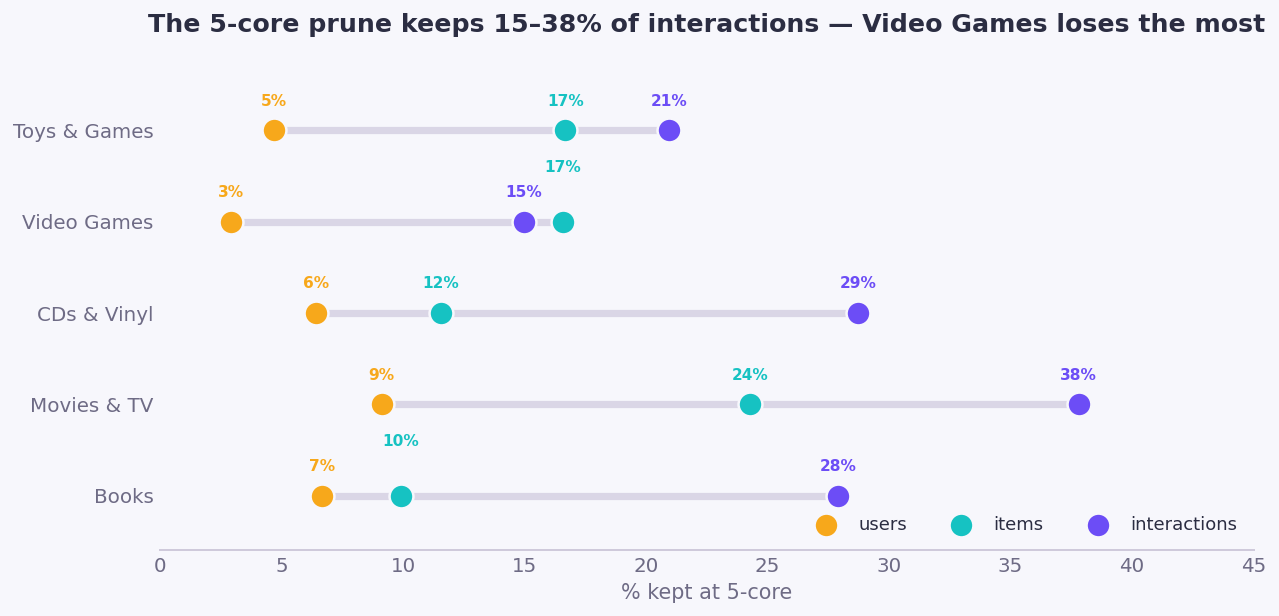

In [13]:
def _ret(v):
    s0, s5 = RAWREV[v], SCALE5[v]
    return [s5['interactions_5core'] / s0['interactions_0core'] * 100,
            s5['users_5core']        / s0['users_0core']        * 100,
            s5['items_5core']        / s0['items_0core']        * 100]
names = ['interactions', 'users', 'items']; dotc = [PURPLE, ORANGE, TEAL]
R = {v: _ret(v) for v in VERTICALS}
fig, ax = plt.subplots(figsize=(10, 4.9))
y = np.arange(len(VERTICALS))
for i, v in enumerate(VERTICALS):
    vals = R[v]
    ax.plot([min(vals), max(vals)], [i, i], color='#DAD6E6', lw=4, zorder=1, solid_capstyle='round')
    placed = []
    for k in sorted(range(3), key=lambda j: vals[j]):
        ax.scatter(vals[k], i, s=175, color=dotc[k], zorder=3, edgecolor=BG, linewidth=1.4,
                   label=names[k] if i == 0 else None)
        near = sum(1 for j in placed if abs(vals[k]-vals[j]) < 3.5)
        ax.annotate(f'{vals[k]:.0f}%', (vals[k], i), xytext=(0, 12+14*near), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8.5, color=dotc[k], fontweight='bold')
        placed.append(k)
ax.set_yticks(y); ax.set_yticklabels([LBL[v] for v in VERTICALS])
ax.set_xlabel('% kept at 5-core'); ax.set_xlim(0, 45); ax.set_ylim(-0.6, len(VERTICALS)-0.2)
ctitle(ax, 'The 5-core prune keeps 15–38% of interactions — Video Games loses the most', size=14)
style_bar_axis(ax, 'x')
brand_legend(ax, ncol=3, loc='lower right')
finish(fig)

## 3 · Processed-data EDA — *what the model actually sees*

The cleaned 5-core tables in `data/processed/`: catalog scale after the prune, the long-tail / cold-start regime that motivates cross-domain transfer, item-feature coverage, and the cross-vertical user overlap per study pair. All read straight from the processed Parquet/NPZ artifacts.

### 3.1 · Catalog scale (after 5-core)

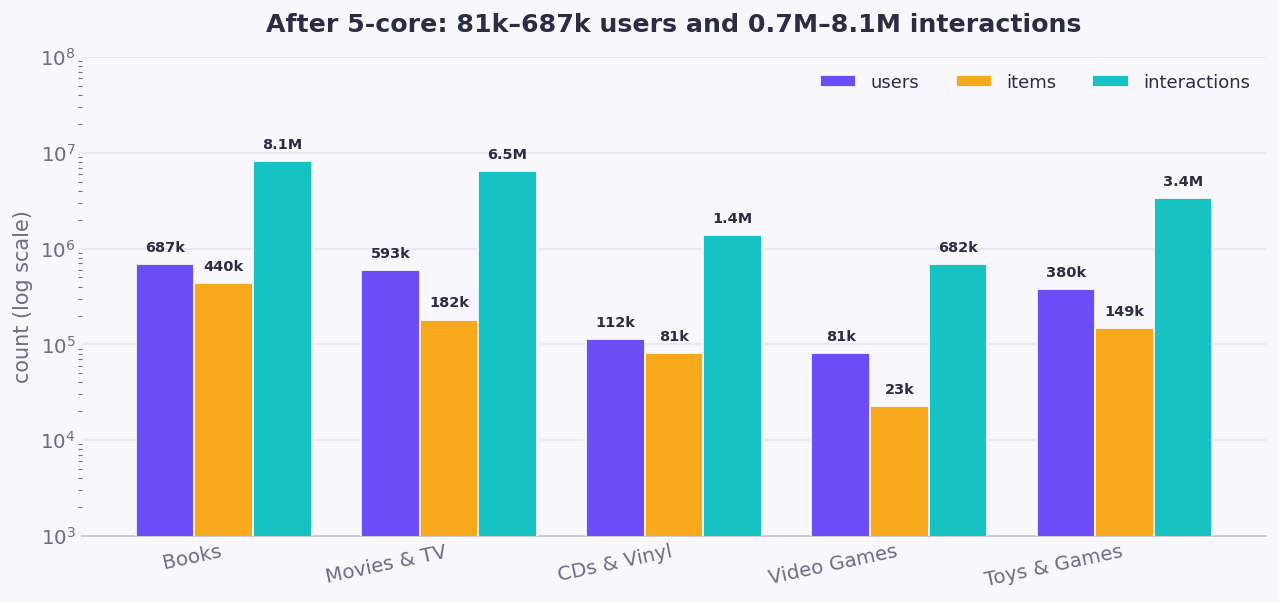

In [14]:
fig, ax = plt.subplots(figsize=(10, 4.8))
metrics = [('users_5core', 'users', PURPLE),
           ('items_5core', 'items', ORANGE),
           ('interactions_5core', 'interactions', TEAL)]
x = np.arange(len(VERTICALS)); w = 0.26
for k, (key, name, col) in enumerate(metrics):
    vals = [SCALE5[v][key] for v in VERTICALS]
    bars = ax.bar(x + (k-1)*w, vals, w, label=name, color=col, edgecolor=BG, zorder=3)
    for b, val in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, val*1.25, kfmt(val), ha='center', va='bottom',
                fontsize=8, color=INK, fontweight='bold')
ax.set_yscale('log'); ax.set_ylim(1e3, 1e8)
ax.set_xticks(x); ax.set_xticklabels([LBL[v] for v in VERTICALS], rotation=12, ha='right')
ax.set_ylabel('count (log scale)')
ctitle(ax, 'After 5-core: 81k–687k users and 0.7M–8.1M interactions', size=14)
style_bar_axis(ax, 'x'); soft_grid(ax, 'y')
brand_legend(ax, ncol=3, loc='upper right')
finish(fig)

### 3.2 · The long tail & cold-start
*Left: how concentrated interactions are — a few items capture most of them. Right: how little history most users have — the cold-start regime cross-domain transfer is built for.* Degrees are computed from the processed positive interactions and cached.

degree cache loaded


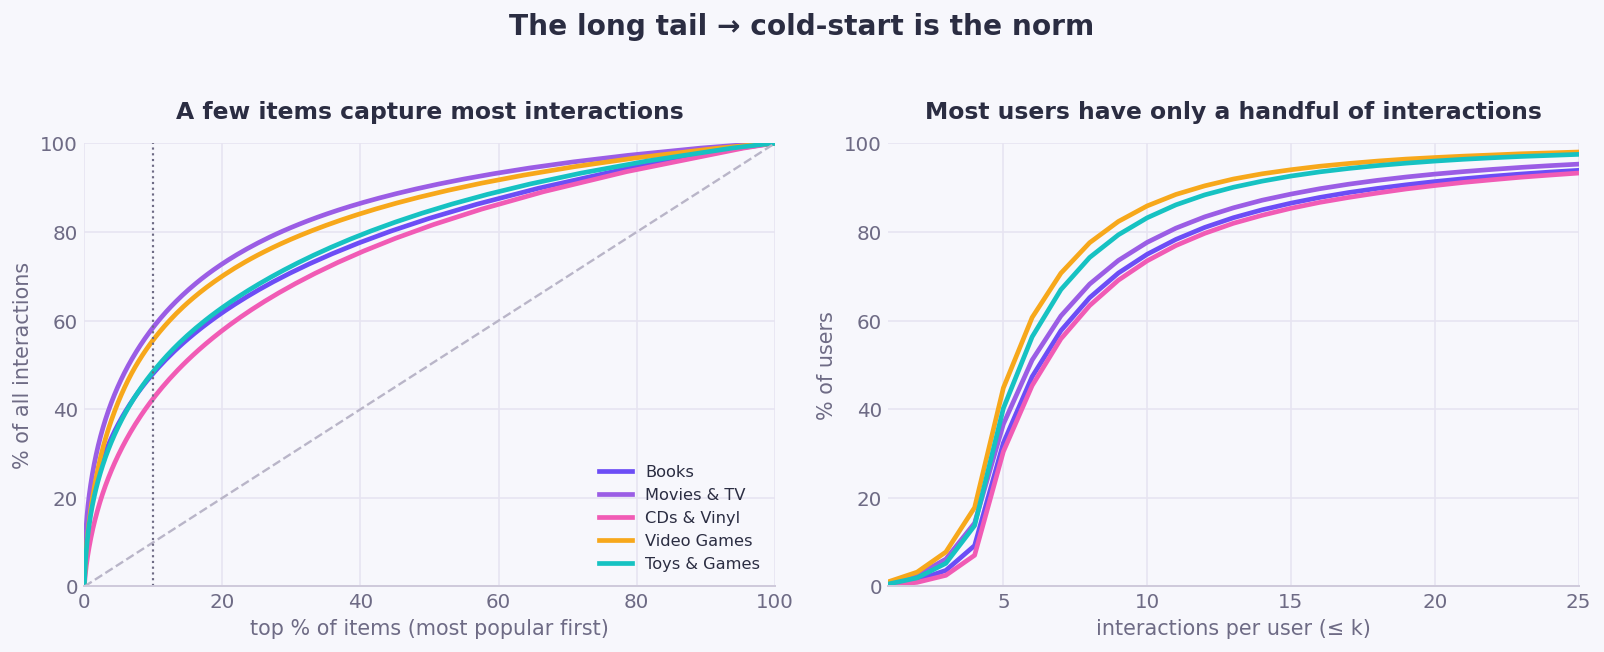

In [15]:
def build_degrees():
    di, du = [], []
    for v in VERTICALS:
        df = pd.read_parquet(f'{PROC}/{v}/interactions.parquet', columns=['user_idx', 'item_idx', 'label'])
        df = df[df['label'] == 1]                                  # positive interactions
        di.append(pd.DataFrame({'vertical': v, 'pop': df['item_idx'].value_counts().values}))
        du.append(pd.DataFrame({'vertical': v, 'deg': df['user_idx'].value_counts().values}))
        del df; gc.collect()
    return pd.concat(di, ignore_index=True), pd.concat(du, ignore_index=True)

if (CACHE / 'deg_item.parquet').exists() and (CACHE / 'deg_user.parquet').exists():
    deg_item = pd.read_parquet(CACHE / 'deg_item.parquet')
    deg_user = pd.read_parquet(CACHE / 'deg_user.parquet')
    print('degree cache loaded')
else:
    print('building degree cache from processed positives…')
    deg_item, deg_user = build_degrees()
    deg_item.to_parquet(CACHE / 'deg_item.parquet'); deg_user.to_parquet(CACHE / 'deg_user.parquet')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9))
for v in VERTICALS:
    pop = np.sort(deg_item[deg_item['vertical'] == v]['pop'].values)[::-1]
    cum = np.cumsum(pop) / pop.sum() * 100
    xf = np.arange(1, len(pop)+1) / len(pop) * 100
    axes[0].plot(xf, cum, color=VCOLORS[v], lw=2.6, label=LBL[v])
axes[0].plot([0, 100], [0, 100], ls='--', color='#B9B5C8', lw=1.3)
axes[0].axvline(10, ls=':', color=INK_SOFT, lw=1.2)
axes[0].set_xlabel('top % of items (most popular first)'); axes[0].set_ylabel('% of all interactions')
axes[0].set_xlim(0, 100); axes[0].set_ylim(0, 100)
ctitle(axes[0], 'A few items capture most interactions', size=13)
style_line_axis(axes[0]); brand_legend(axes[0], fontsize=9, loc='lower right')
ks = np.arange(1, 26)
for v in VERTICALS:
    deg = deg_user[deg_user['vertical'] == v]['deg'].values
    axes[1].plot(ks, [(deg <= k).mean()*100 for k in ks], color=VCOLORS[v], lw=2.6, label=LBL[v])
axes[1].set_xlabel('interactions per user (≤ k)'); axes[1].set_ylabel('% of users')
axes[1].set_xlim(1, 25); axes[1].set_ylim(0, 100)
ctitle(axes[1], 'Most users have only a handful of interactions', size=13)
style_line_axis(axes[1])
fig.suptitle('The long tail → cold-start is the norm', color=INK, fontsize=15.5, fontweight='bold', y=1.02)
finish(fig)

### 3.3 · Item-feature coverage
Each kept item carries a MiniLM text embedding, a shared-vocab category multi-hot, and popularity priors. Read from `item_features.npz`: how much text is real vs. fallback vs. placeholder, and how many category tags an item carries on average.

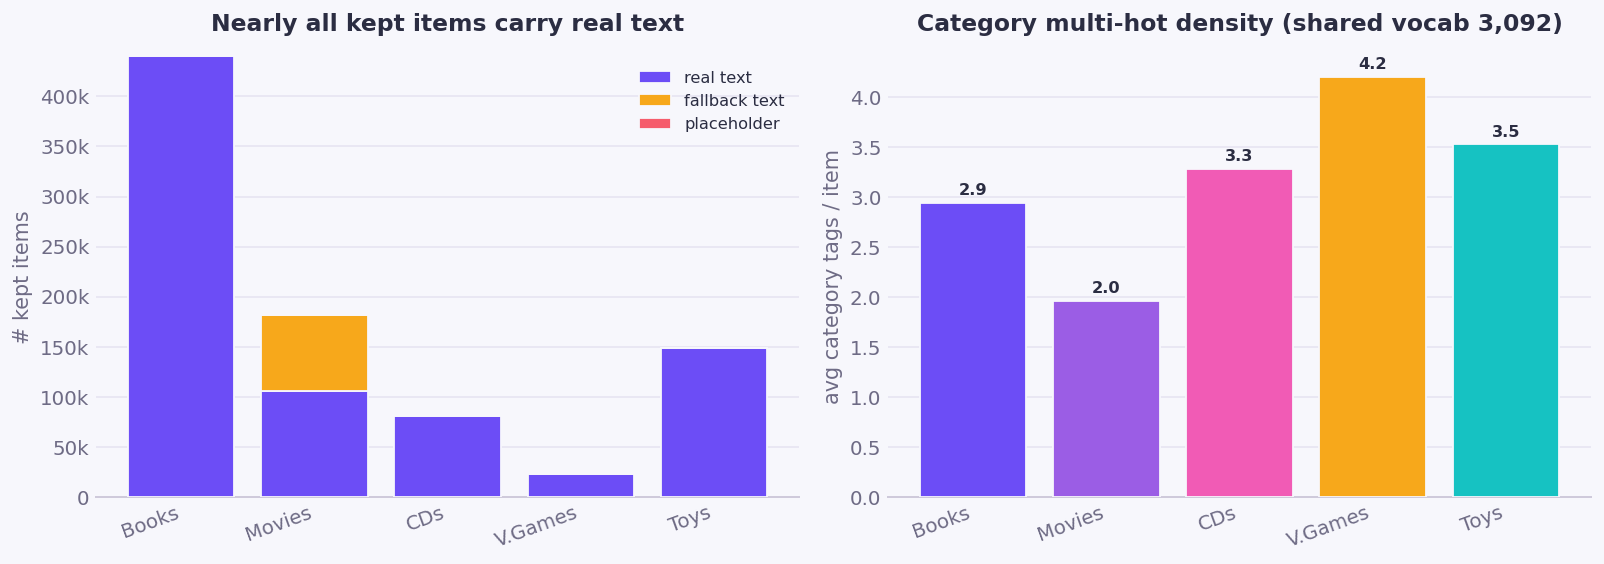

In [16]:
def feat_cov(v):
    z = np.load(f'{PROC}/{v}/item_features.npz', allow_pickle=True)
    c = Counter(z['text_source'].tolist())
    n = len(z['text_source'])
    return {'primary': c.get('primary', 0), 'fallback': c.get('fallback', 0), 'none': c.get('none', 0),
            'n': n, 'vocab': int(z['cat_shape'][1]), 'mean_cats': len(z['cat_indices']) / n}

FEAT = {v: feat_cov(v) for v in VERTICALS}
for v in VERTICALS:
    check(f'{v}.text_primary',  FEAT[v]['primary'],  dcln(v)['text_primary'])
    check(f'{v}.text_fallback', FEAT[v]['fallback'], dcln(v)['text_fallback'])
    check(f'{v}.text_none',     FEAT[v]['none'],     dcln(v)['text_none_placeholder'])
check('category_vocab_size', FEAT['Books']['vocab'], DESC['category_vocab_size'])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
prim = [FEAT[v]['primary'] for v in VERTICALS]
fall = [FEAT[v]['fallback'] for v in VERTICALS]
ph   = [FEAT[v]['none'] for v in VERTICALS]
x = np.arange(len(VERTICALS))
axes[0].bar(x, prim, color=PURPLE, edgecolor=BG, label='real text', zorder=3)
axes[0].bar(x, fall, bottom=prim, color=ORANGE, edgecolor=BG, label='fallback text', zorder=3)
axes[0].bar(x, ph, bottom=np.array(prim)+np.array(fall), color=CORAL, edgecolor=BG, label='placeholder', zorder=3)
axes[0].set_xticks(x); axes[0].set_xticklabels([SHORT[v] for v in VERTICALS], rotation=20, ha='right')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: kfmt(v)))
axes[0].set_ylabel('# kept items'); ctitle(axes[0], 'Nearly all kept items carry real text', size=13)
style_bar_axis(axes[0], 'x'); soft_grid(axes[0], 'y'); brand_legend(axes[0], fontsize=9)
mc = [FEAT[v]['mean_cats'] for v in VERTICALS]
bars = axes[1].bar(x, mc, color=[VCOLORS[v] for v in VERTICALS], edgecolor=BG, zorder=3)
bar_annotated(axes[1], bars, mc, fmt='{:.1f}', fs=9)
axes[1].set_xticks(x); axes[1].set_xticklabels([SHORT[v] for v in VERTICALS], rotation=20, ha='right')
axes[1].set_ylabel('avg category tags / item')
ctitle(axes[1], f'Category multi-hot density (shared vocab {FEAT["Books"]["vocab"]:,})', size=13)
style_bar_axis(axes[1], 'x'); soft_grid(axes[1], 'y')
finish(fig)

### 3.4 · Shared users & overlap structure
Per study pair (5-core), how many users bridge the two verticals — and how thin that overlap is against each vertical's single-domain population. Counts come from each pair's `roles.parquet`.

In [17]:
def pair_roles(s, t):
    r = pq.read_table(f'{PROC}/pairs/{s}__{t}/roles.parquet', columns=['role'])['role'].to_numpy()
    c = Counter(r.tolist())
    return {'shared': c.get('overlap', 0), 'src_only': c.get('source_only', 0), 'tgt_only': c.get('target_only', 0)}

ROLES = {}
for s, t in PAIRS_FULL:
    ROLES[(s, t)] = pair_roles(s, t)
    check(f'{plabel(s,t)} shared_users', ROLES[(s, t)]['shared'],   dpair(s, t)['shared_users'])
    check(f'{plabel(s,t)} src_only',     ROLES[(s, t)]['src_only'], dpair(s, t)['src_only_users'])
    check(f'{plabel(s,t)} tgt_only',     ROLES[(s, t)]['tgt_only'], dpair(s, t)['tgt_only_users'])
print('pair roles loaded for', len(ROLES), 'pairs')

pair roles loaded for 8 pairs


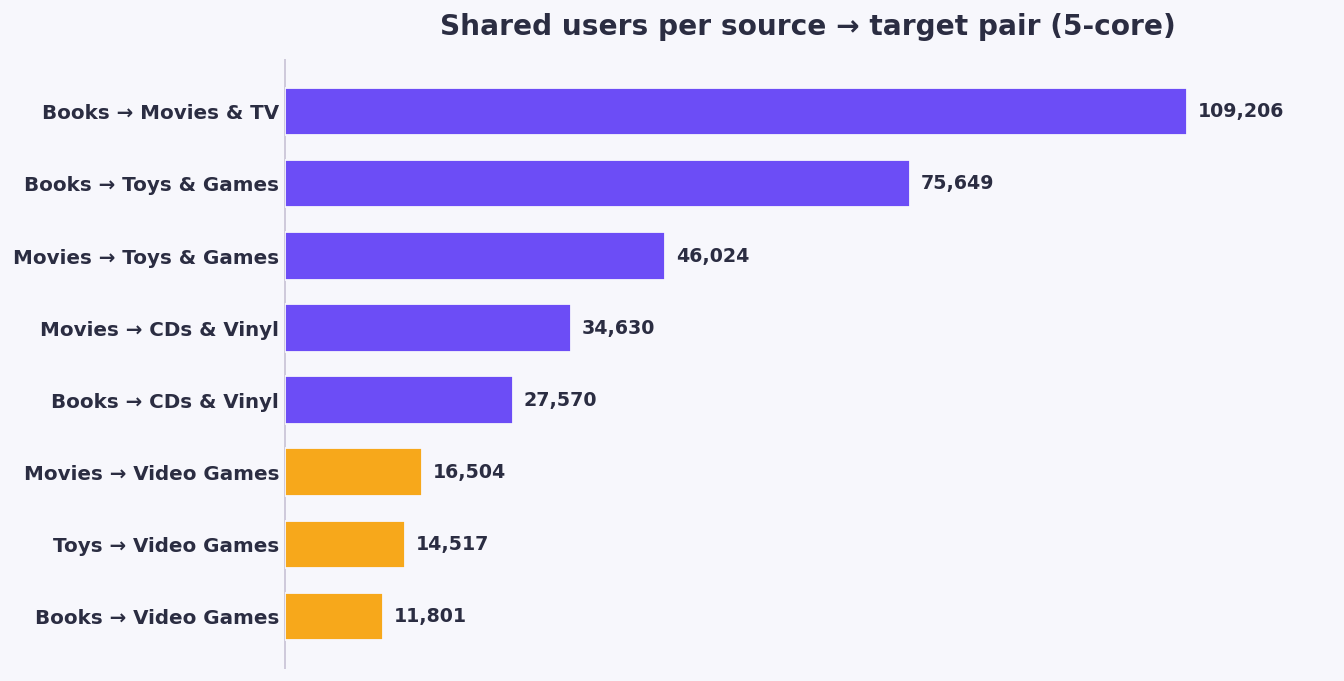

In [18]:
rows = [(s, t, ROLES[(s, t)]['shared']) for s, t in PAIRS_FULL]
rows.sort(key=lambda r: r[2])                       # ascending -> largest ends on top
labels = [arr_lbl(s, t) for s, t, _ in rows]
shared = [r[2] for r in rows]
y = np.arange(len(rows))
colors = [ORANGE if t == 'Video_Games' else PURPLE for s, t, _ in rows]   # highlight below-cliff pairs
fig, ax = plt.subplots(figsize=(10.5, 5.4))
bars = ax.barh(y, shared, color=colors, edgecolor=BG, height=0.66, zorder=3)
for b, s in zip(bars, shared):
    ax.text(s + max(shared)*0.012, b.get_y()+b.get_height()/2, f'{s:,}',
            va='center', fontsize=10.5, color=INK, fontweight='bold')
ax.set_yticks(y); ax.set_yticklabels(labels, fontweight='bold', color=INK)
ax.set_xlim(0, max(shared)*1.16); ax.set_xticks([])
ctitle(ax, 'Shared users per source → target pair (5-core)', size=15.5)
style_bar_axis(ax, 'y')
finish(fig)

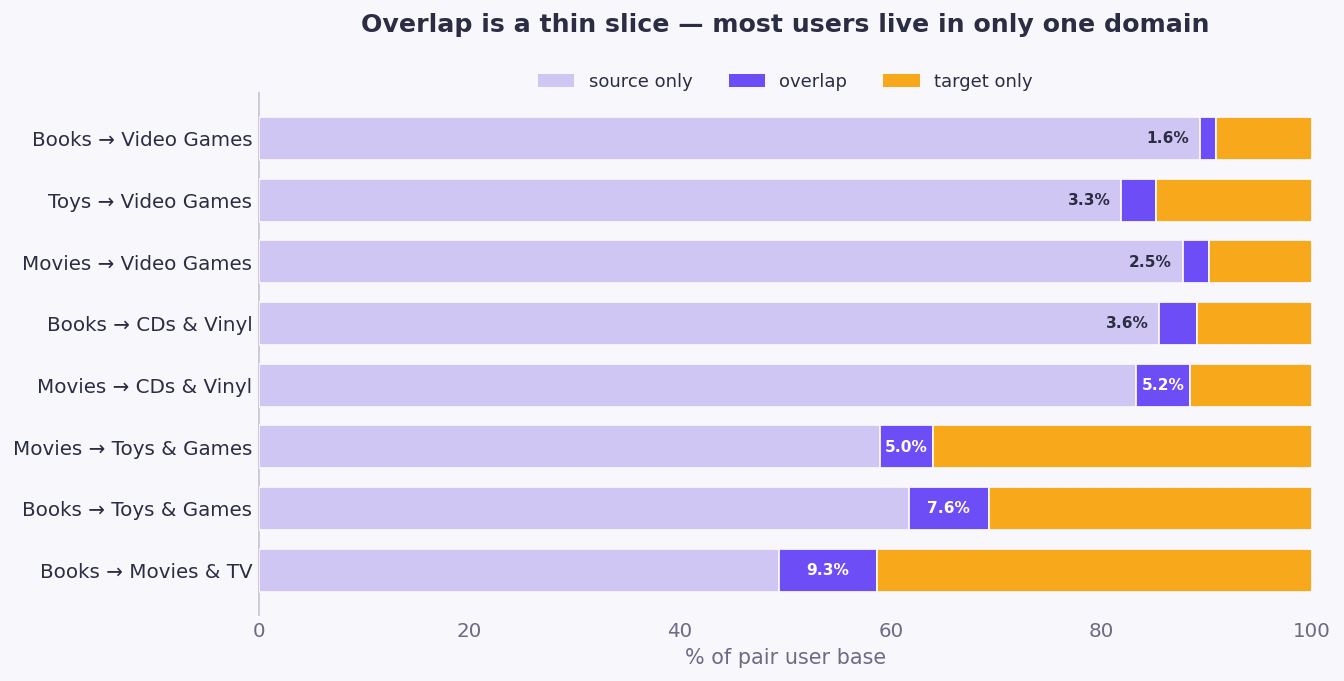

In [19]:
fig, ax = plt.subplots(figsize=(10.5, 5.4))
y = np.arange(len(PAIRS_FULL))
SRC_C, OVL_C, TGT_C = '#CFC6F4', PURPLE, ORANGE
for i, (s, t) in enumerate(PAIRS_FULL):
    r = ROLES[(s, t)]; tot = r['src_only'] + r['shared'] + r['tgt_only']
    segs = [r['src_only']/tot*100, r['shared']/tot*100, r['tgt_only']/tot*100]
    left = 0
    for w, c in zip(segs, [SRC_C, OVL_C, TGT_C]):
        ax.barh(i, w, left=left, color=c, edgecolor=BG, height=0.7, zorder=3); left += w
    ov0, ov1 = segs[0], segs[0]+segs[1]
    if segs[1] >= 4.5:
        ax.text((ov0+ov1)/2, i, f'{segs[1]:.1f}%', va='center', ha='center',
                fontsize=8.5, color='white', fontweight='bold')
    else:
        ax.text(ov0-1.0, i, f'{segs[1]:.1f}%', va='center', ha='right',
                fontsize=8.5, color=INK, fontweight='bold')
ax.set_yticks(y); ax.set_yticklabels([arr_lbl(s, t) for s, t in PAIRS_FULL], color=INK)
ax.set_xlim(0, 100); ax.set_xlabel('% of pair user base')
ctitle(ax, 'Overlap is a thin slice — most users live in only one domain', size=14, pad=34)
style_bar_axis(ax, 'y')
brand_legend(ax, handles=[Patch(facecolor=SRC_C, label='source only'),
                          Patch(facecolor=OVL_C, label='overlap'),
                          Patch(facecolor=TGT_C, label='target only')],
             ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.07))
finish(fig)

## 4 · Baselines
Four reference points per pair, in increasing sophistication: **Random**, **MostPop** (raw popularity, the deployed fallback), **target-MF** (the average target user — a popularity prior in embedding space, *uses no source info*), and **content-transfer** (training-free cosine between the source liked-item text and target item text — a simple content CDR). Numbers come from `results/SUMMARY.json`, written by the experiment grid (`src/cdr/run_grid.py`).

In [20]:
# ── Results access (reads results/SUMMARY.json — the experiment-grid output) ──
_GRID = {}
def load_grid(tag):
    if not _GRID:
        _GRID.update(json.load(open(RES / 'SUMMARY.json'))['grids'])
    return _GRID[tag]

def entry(tag, src, tgt, ablation='full'):
    for r in load_grid(tag):
        if r['src'] == src and r['tgt'] == tgt and r['ablation'] == ablation:
            return r
    raise KeyError((tag, src, tgt, ablation))

def mval(e, model, metric=HEADLINE):
    m = e['metrics'].get(model)
    return float(m[metric]['mean']) if m else float('nan')

BASELINES = ['baseline_target_mf', 'baseline_feature_transfer',
             'baseline_mostpop', 'baseline_random']
ALLMODELS = ['emcdr'] + BASELINES

def winner_of(e, metric=HEADLINE):
    c = {m: mval(e, m, metric) for m in ALLMODELS if m in e['metrics']}
    return max(c, key=c.get)

def best_baseline(e, metric=HEADLINE):
    c = {m: mval(e, m, metric) for m in BASELINES if m in e['metrics']}
    return max(c, key=c.get)

def entries_for(tag, pairs, ablation='full'):
    return [entry(tag, s, t, ablation) for s, t in pairs]

def grouped_models(ax, pairs, ents, models, ylabel, title, annotate='emcdr', metric=HEADLINE):
    x = np.arange(len(pairs)); n = len(models); w = 0.82/n
    for k, m in enumerate(models):
        vals = [mval(e, m, metric) for e in ents]
        bars = ax.bar(x + (k-(n-1)/2)*w, vals, w, label=MODEL_LBL[m],
                      color=MODEL_COLORS[m], edgecolor=BG, linewidth=0.8, zorder=3)
        if m == annotate:
            bar_annotated(ax, bars, vals, fmt='{:.2f}', fs=8.5)
    ax.set_xticks(x); ax.set_xticklabels([plabel(s, t) for s, t in pairs], rotation=20, ha='right')
    ax.set_ylabel(ylabel); ctitle(ax, title, size=14)
    style_bar_axis(ax, 'x'); soft_grid(ax, 'y')
    brand_legend(ax, ncol=len(models), fontsize=9.5, loc='upper center',
                 bbox_to_anchor=(0.5, 1.0), handletextpad=0.5, columnspacing=1.2)
print('results helpers ready · grids:', list(json.load(open(RES / "SUMMARY.json"))["grids"].keys()))

results helpers ready · grids: ['full', 'improve_lin', 'b1', 'b1_3core']


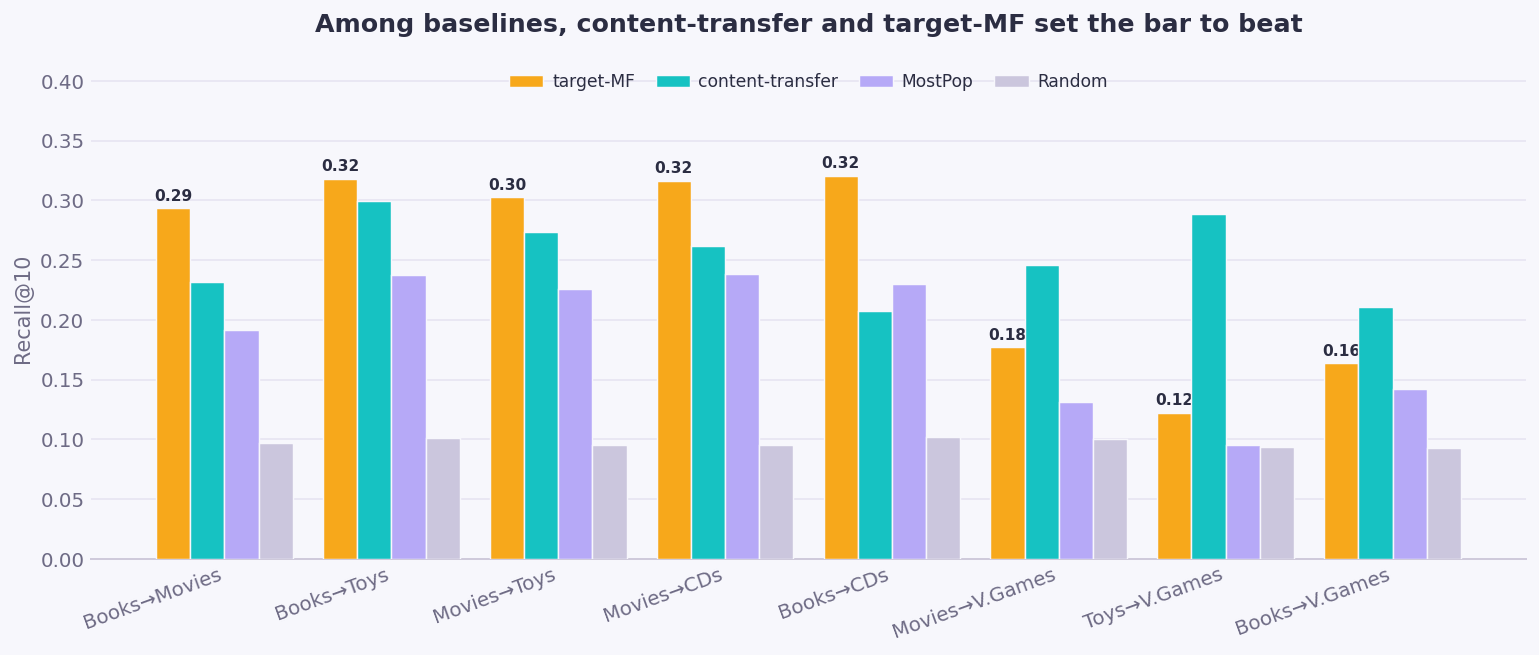

In [21]:
fig, ax = plt.subplots(figsize=(12, 5.2))
ents = entries_for('improve_lin', PAIRS_FULL)
grouped_models(ax, PAIRS_FULL, ents, BASELINES, 'Recall@10',
               'Among baselines, content-transfer and target-MF set the bar to beat',
               annotate='baseline_target_mf')
ax.set_ylim(0, 0.42)
finish(fig)

## 5 · Our solution — EMCDR
Train a recommender per vertical, then learn a mapping `f` from a shared user's **source** embedding to their **target** embedding. For a cold target user we map their source vector and score it against the target catalog. Items are grounded in content (MiniLM text + categories + popularity).

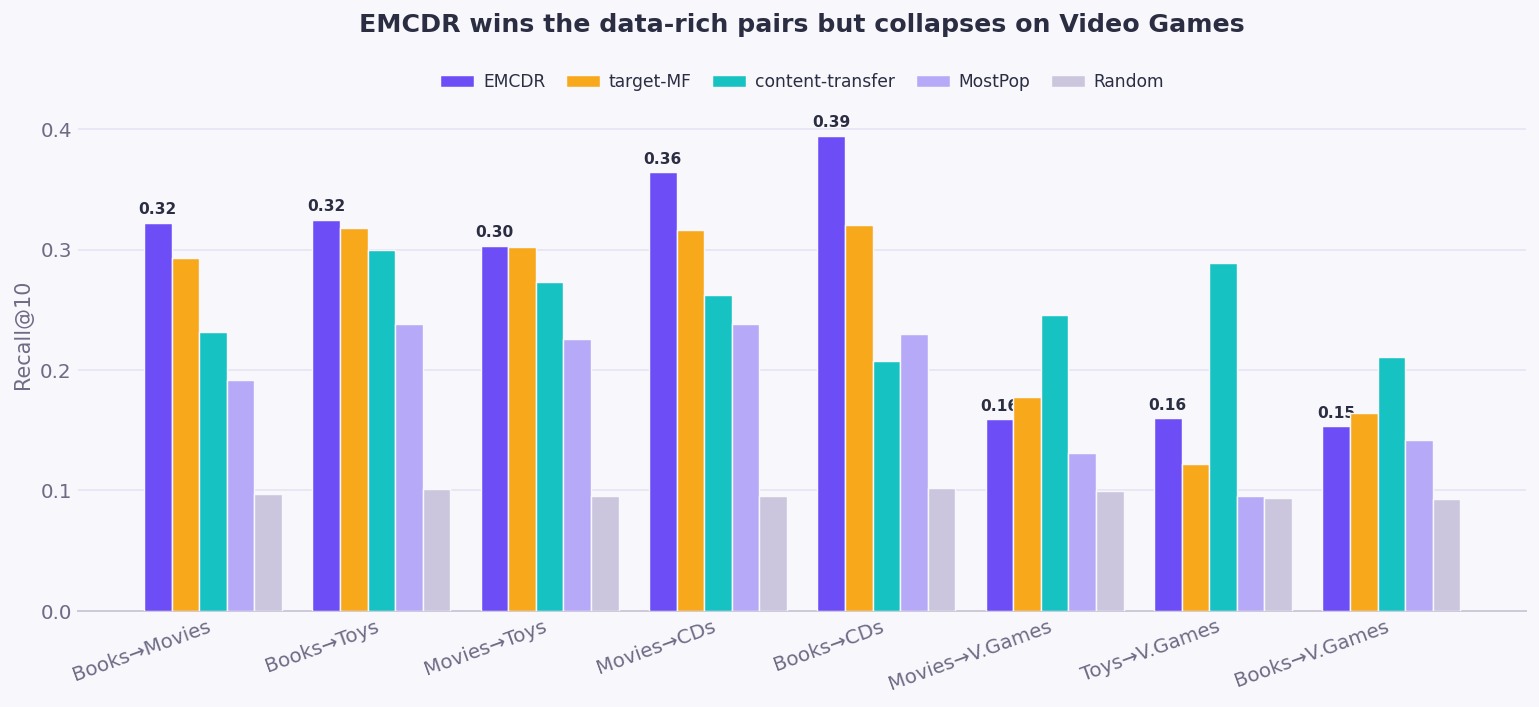

In [22]:
# EMCDR vs all baselines (regularized-linear mapping)
fig, ax = plt.subplots(figsize=(12, 5.6))
ents = entries_for('improve_lin', PAIRS_FULL)
grouped_models(ax, PAIRS_FULL, ents, ALLMODELS, 'Recall@10',
               'EMCDR wins the data-rich pairs but collapses on Video Games')
ax.set_ylim(0, 0.46)
finish(fig)

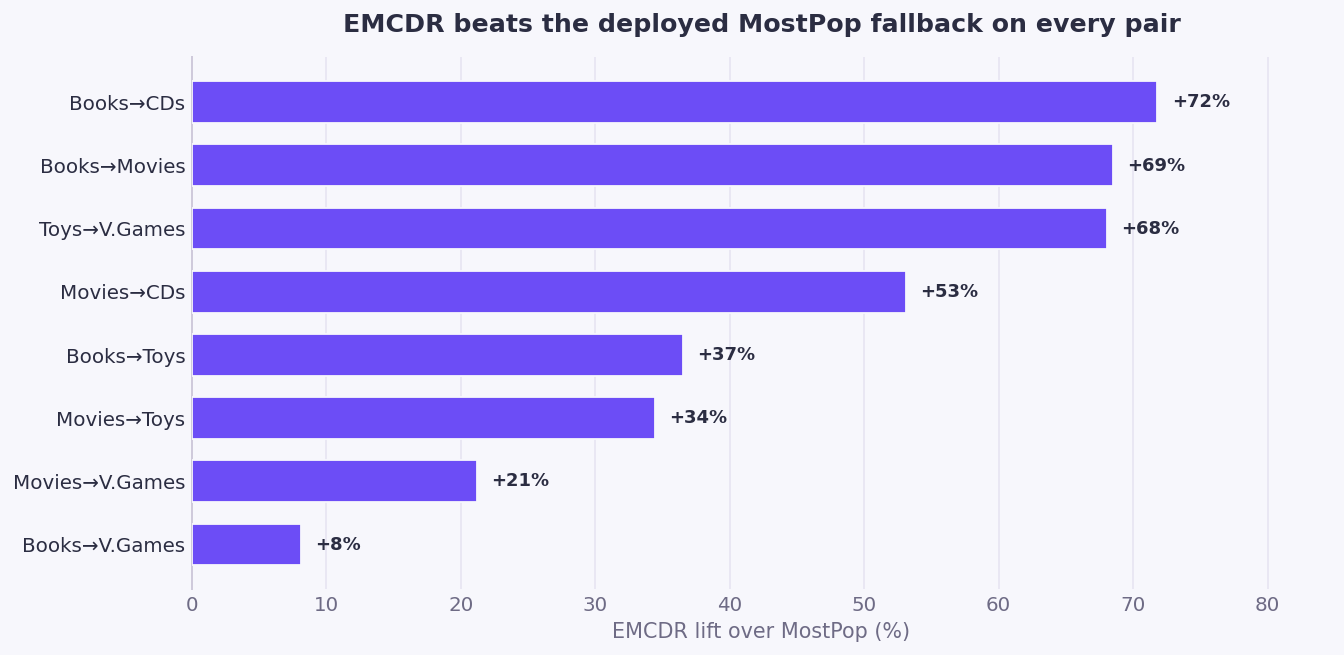

In [23]:
# lift over MostPop — EMCDR clears the deployed fallback on every pair
fig, ax = plt.subplots(figsize=(10.5, 5.2))
ents = entries_for('improve_lin', PAIRS_FULL)
lift = [(mval(e, 'emcdr') - mval(e, 'baseline_mostpop')) / mval(e, 'baseline_mostpop') * 100 for e in ents]
order = np.argsort(lift)
y = np.arange(len(ents))
ax.barh(y, np.array(lift)[order], color=PURPLE, edgecolor=BG, height=0.66, zorder=3)
ax.set_yticks(y); ax.set_yticklabels([plabel(*PAIRS_FULL[i]) for i in order], color=INK)
for i, val in enumerate(np.array(lift)[order]):
    ax.text(val + max(lift)*0.015, i, f'+{val:.0f}%', va='center', fontsize=10, color=INK, fontweight='bold')
ax.set_xlim(0, max(lift)*1.18); ax.set_xlabel('EMCDR lift over MostPop (%)')
ctitle(ax, 'EMCDR beats the deployed MostPop fallback on every pair', size=14)
style_bar_axis(ax, 'y'); soft_grid(ax, 'x')
finish(fig)

## 6 · Improvements & the honest boundary
Three targeted fixes: **A1** a regularized *linear* mapping (rich pairs), **B1** a content-grounded target item tower, and **B2** a denser 3-core Video-Games target (~2× overlap).

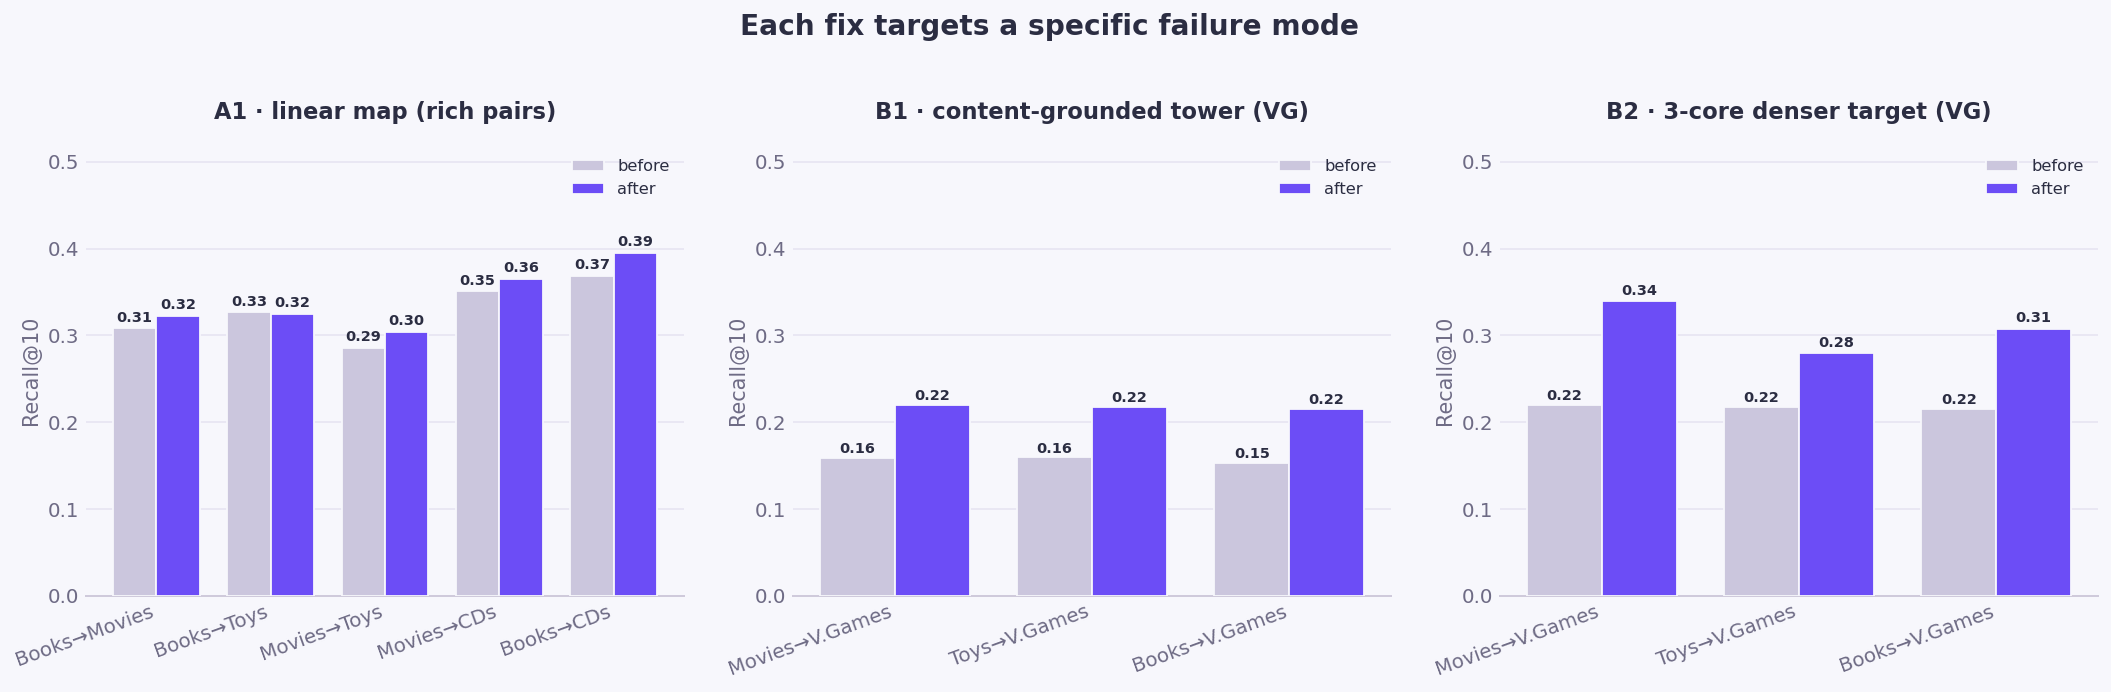

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2))
def beforeafter(ax, title, items):
    x = np.arange(len(items)); w = 0.38
    bef = [b for _, b, _ in items]; aft = [a for _, _, a in items]
    b1 = ax.bar(x - w/2, bef, w, label='before', color=NEUTRAL, edgecolor=BG, zorder=3)
    b2 = ax.bar(x + w/2, aft, w, label='after', color=PURPLE, edgecolor=BG, zorder=3)
    bar_annotated(ax, b1, bef, fmt='{:.2f}', fs=8); bar_annotated(ax, b2, aft, fmt='{:.2f}', fs=8)
    ax.set_xticks(x); ax.set_xticklabels([n for n, _, _ in items], rotation=20, ha='right')
    ax.set_ylabel('Recall@10'); ax.set_ylim(0, 0.52)
    ctitle(ax, title, size=12.5)
    style_bar_axis(ax, 'x'); soft_grid(ax, 'y')
    brand_legend(ax, loc='upper right', fontsize=9)

RICH = PAIRS_FULL[:5]
a1 = [(plabel(s, t), mval(entry('full', s, t), 'emcdr'), mval(entry('improve_lin', s, t), 'emcdr')) for s, t in RICH]
beforeafter(axes[0], 'A1 · linear map (rich pairs)', a1)

VG = [('Movies_and_TV','Video_Games'), ('Toys_and_Games','Video_Games'), ('Books','Video_Games')]
b1 = [(plabel(s, t), mval(entry('improve_lin', s, t), 'emcdr'), mval(entry('b1', s, t), 'emcdr')) for s, t in VG]
beforeafter(axes[1], 'B1 · content-grounded tower (VG)', b1)

b2 = [(plabel(s, 'Video_Games'),
       mval(entry('b1', s, 'Video_Games'), 'emcdr'),
       mval(entry('b1_3core', s, 'Video_Games_3core'), 'emcdr')) for s in ['Movies_and_TV', 'Toys_and_Games', 'Books']]
beforeafter(axes[2], 'B2 · 3-core denser target (VG)', b2)
fig.suptitle('Each fix targets a specific failure mode', color=INK, fontsize=15.5, fontweight='bold', y=1.02)
finish(fig)

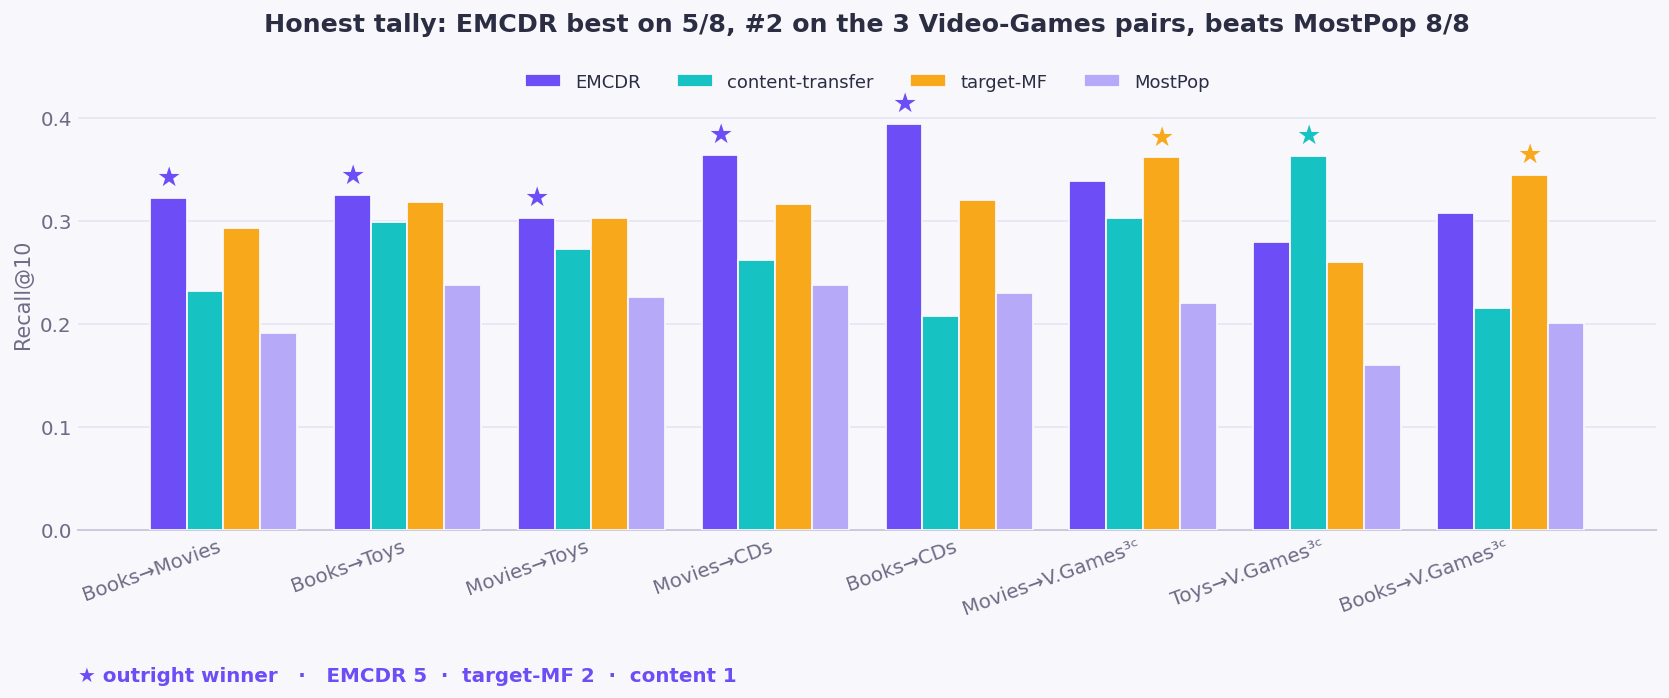

In [25]:
# honest final tally — best deployed config per pair
fig, ax = plt.subplots(figsize=(13, 5.8))
cols = ['emcdr', 'baseline_feature_transfer', 'baseline_target_mf', 'baseline_mostpop']
x = np.arange(len(DEPLOYED)); w = 0.2
tally = {}
for k, m in enumerate(cols):
    vals = [mval(entry(tag, s, t), m) for s, t, tag in DEPLOYED]
    ax.bar(x + (k-1.5)*w, vals, w, label=MODEL_LBL[m], color=MODEL_COLORS[m], edgecolor=BG, zorder=3)
for i, (s, t, tag) in enumerate(DEPLOYED):
    e = entry(tag, s, t); win = winner_of(e); tally[win] = tally.get(win, 0) + 1
    kw = cols.index(win) if win in cols else 1.5                # align star to the winning bar
    ax.text(x[i] + (kw-1.5)*w, mval(e, win) + 0.012, '★', ha='center', fontsize=15,
            color=MODEL_COLORS[win])
ax.set_xticks(x); ax.set_xticklabels([plabel(s, t) for s, t, _ in DEPLOYED], rotation=20, ha='right')
ax.set_ylabel('Recall@10'); ax.set_ylim(0, 0.46)
ctitle(ax, 'Honest tally: EMCDR best on 5/8, #2 on the 3 Video-Games pairs, beats MostPop 8/8', size=14)
style_bar_axis(ax, 'x'); soft_grid(ax, 'y')
brand_legend(ax, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.0))
txt = (f"★ outright winner   ·   EMCDR {tally.get('emcdr',0)}  ·  "
       f"target-MF {tally.get('baseline_target_mf',0)}  ·  content {tally.get('baseline_feature_transfer',0)}")
ax.text(0.0, -0.32, txt, transform=ax.transAxes, fontsize=11, color=PURPLE, fontweight='bold')
finish(fig)

## Takeaways
- **Cross-domain transfer pays off where the theory says it should** — high overlap *and* a content-rich
  target: EMCDR is the outright best model on the 5 rich pairs and beats the deployed MostPop fallback 8/8.
- **On sparse targets a popularity prior is hard to beat** — on the 3 Video-Games pairs EMCDR is a close #2;
  target-MF / content win. Doubling the overlap (3-core) didn't change the verdict → it's the sparse target,
  not the sample size.
- **The winner is predictable a priori from overlap size** → deploy EMCDR above the cliff, fall back to the
  popularity prior below it.

In [26]:
# ── verification: tallies match the docs ──
full_wins     = [winner_of(entry('full', s, t))        for s, t in PAIRS_FULL]
improved_wins = [winner_of(entry('improve_lin', s, t)) for s, t in PAIRS_FULL]
dep_wins      = [winner_of(entry(tag, s, t))           for s, t, tag in DEPLOYED]
from collections import Counter
print('base-run EMCDR outright wins     :', full_wins.count('emcdr'),     '/ 8   (expect 4)')
print('improved (linear-map) EMCDR wins :', improved_wins.count('emcdr'), '/ 8   (expect 5)')
print('deployed winners                 :', dict(Counter(dep_wins)))
print('EMCDR beats MostPop on           :',
      sum(mval(entry(tag, s, t), 'emcdr') > mval(entry(tag, s, t), 'baseline_mostpop')
          for s, t, tag in DEPLOYED), '/ 8')
assert full_wins.count('emcdr') == 4
assert improved_wins.count('emcdr') == 5
assert Counter(dep_wins) == {'emcdr': 5, 'baseline_target_mf': 2, 'baseline_feature_transfer': 1}
print('OK — numbers match RESULTS.md / IMPROVEMENTS.md')

base-run EMCDR outright wins     : 4 / 8   (expect 4)
improved (linear-map) EMCDR wins : 5 / 8   (expect 5)
deployed winners                 : {'emcdr': 5, 'baseline_target_mf': 2, 'baseline_feature_transfer': 1}
EMCDR beats MostPop on           : 8 / 8
OK — numbers match RESULTS.md / IMPROVEMENTS.md


## Verification — live figures vs. the §3 preprocessing artifact
Every EDA number plotted above was computed in-notebook from `data/raw` / `data/processed`. This cell cross-checks each one against `dataset_description.json` (written by `notebooks/data_prep.ipynb`, which consumes `eda.ipynb`'s 5-core/overlap pass) and asserts they match — so any discrepancy fails loudly.

In [27]:
n_ok = sum(ok for *_ , ok in CHECKS)
print(f'{"check":52s} {"computed":>14s} {"reference":>14s}   ok')
print('-' * 90)
for name, c, r, ok in CHECKS:
    cs = f'{c:,}' if isinstance(c, int) else str(c)
    rs = f'{r:,}' if isinstance(r, int) else str(r)
    print(f'{name:52s} {cs:>14s} {rs:>14s}   {"OK" if ok else "XX  MISMATCH"}')
print('-' * 90)
print(f'{n_ok}/{len(CHECKS)} live-vs-preprocessing cross-checks pass'
      f'  ·  {"ALL MATCH" if n_ok == len(CHECKS) else "DISCREPANCIES FOUND"}')
assert n_ok == len(CHECKS), 'EDA figures disagree with dataset_description.json'
print('OK — every in-notebook EDA number matches eda.ipynb / data_prep.ipynb')

check                                                      computed      reference   ok
------------------------------------------------------------------------------------------
Books.users_0core                                        10,297,355     10,297,355   OK
Books.items_0core                                         4,446,065      4,446,065   OK
Books.interactions_0core                                 29,139,329     29,139,329   OK
Movies_and_TV.users_0core                                 6,503,429      6,503,429   OK
Movies_and_TV.items_0core                                   747,764        747,764   OK
Movies_and_TV.interactions_0core                         17,158,519     17,158,519   OK
CDs_and_Vinyl.users_0core                                 1,754,118      1,754,118   OK
CDs_and_Vinyl.items_0core                                   701,673        701,673   OK
CDs_and_Vinyl.interactions_0core                          4,772,071      4,772,071   OK
Video_Games.users_0core      